### Task 1: Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pf = pd.read_csv('loan_risk_dataset.csv')
print(pf.head())
print(pf.info())

   Customer_ID  Age  Gender  Income Employment_Status  Loan_Amount  Loan_Term  \
0         1001   59    Male   82711          Employed      1437682         24   
1         1002   49    Male  317683          Employed      1176871         12   
2         1003   35    Male  234423        Unemployed      1162383         36   
3         1004   28  Female  229426          Employed      2354656          6   
4         1005   41  Female  438207          Employed      2149365         60   

   Credit_Score Previous_Default Loan_Purpose  Monthly_Installment Defaulted  
0           408              Yes          Car             59903.42       Yes  
1           445              Yes          Car             98072.58       Yes  
2           410               No     Business             32288.42       Yes  
3           527               No     Business            392442.67       Yes  
4           410               No     Personal             35822.75        No  
<class 'pandas.core.frame.DataFrame'>
R

In [2]:
pf.isnull().sum()

Customer_ID            0
Age                    0
Gender                 0
Income                 0
Employment_Status      0
Loan_Amount            0
Loan_Term              0
Credit_Score           0
Previous_Default       0
Loan_Purpose           0
Monthly_Installment    0
Defaulted              0
dtype: int64

In [3]:
pf.duplicated().sum()

0

In [4]:
pf=pf.drop_duplicates()

In [5]:
print(pf['Gender'].unique())
print(pf['Employment_Status'].unique())
print(pf['Previous_Default'].unique())
print(pf['Defaulted'].unique())
text_cols = ['Gender', 'Employment_Status', 'Previous_Default', 'Loan_Purpose', 'Defaulted']

for col in text_cols:
    pf[col] = pf[col].str.strip().str.title()

['Male' 'Female']
['Employed' 'Unemployed' 'Self-Employed']
['Yes' 'No']
['Yes' 'No']


In [6]:
pf['Customer_ID'] = pf['Customer_ID'].astype(str)

In [7]:
pf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          150 non-null    object 
 1   Age                  150 non-null    int64  
 2   Gender               150 non-null    object 
 3   Income               150 non-null    int64  
 4   Employment_Status    150 non-null    object 
 5   Loan_Amount          150 non-null    int64  
 6   Loan_Term            150 non-null    int64  
 7   Credit_Score         150 non-null    int64  
 8   Previous_Default     150 non-null    object 
 9   Loan_Purpose         150 non-null    object 
 10  Monthly_Installment  150 non-null    float64
 11  Defaulted            150 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 14.2+ KB


### Task 2: Exploratory Data Analysis (EDA)

In [8]:
avg_loan = pf['Loan_Amount'].mean()
print(f"Average loan amount :{avg_loan:,.2f}")

Average loan amount :1,454,060.16


### Q2

In [9]:
emp_loan = pf.groupby('Employment_Status')['Loan_Amount'].mean().sort_values(ascending=False)
print("\nAverage Loan by Employment:")
print(emp_loan)


Average Loan by Employment:
Employment_Status
Self-Employed    1.538741e+06
Employed         1.467818e+06
Unemployed       1.265299e+06
Name: Loan_Amount, dtype: float64


### Q3

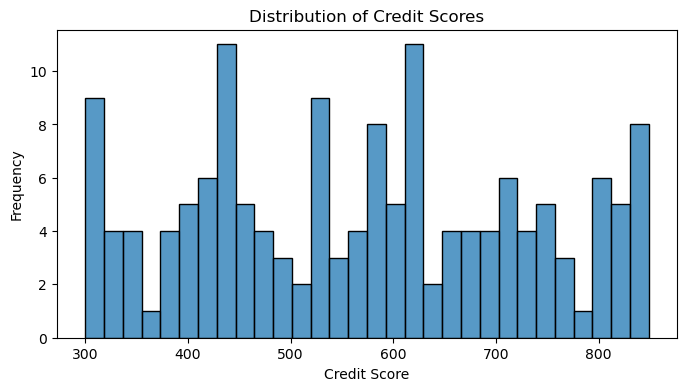

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(pf['Credit_Score'], bins=30)
plt.xlabel('Credit Score')
plt.ylabel('Frequency')
plt.title('Distribution of Credit Scores')
plt.show()

### Q4

Loan_Purpose
Car          44
Education    39
Business     36
Personal     31
Name: count, dtype: int64


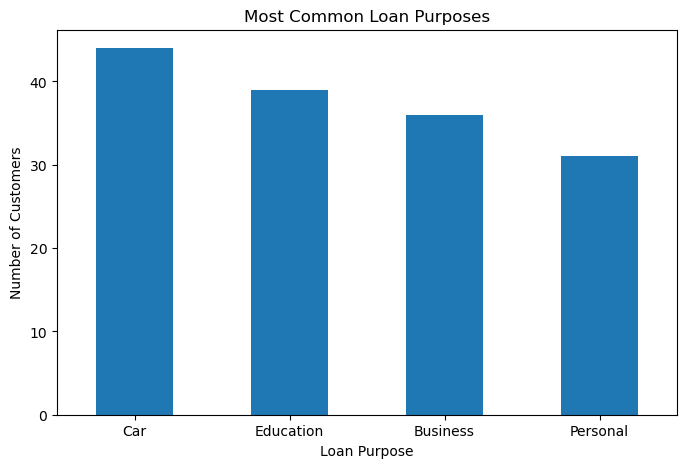

In [11]:
loan_purpose = pf['Loan_Purpose'].value_counts()
print(loan_purpose)
loan_purpose.plot(kind='bar',figsize=(8,5))
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Customers')
plt.title('Most Common Loan Purposes')
plt.xticks(rotation=0)
plt.show()

### Task 3: Risk Analysis

Credit_Group
Low       61.818182
Medium    38.297872
High      36.170213
Name: Defaulted, dtype: float64


C:\Users\hp\AppData\Local\Temp\ipykernel_20380\2664791251.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  credit_risk = pf.groupby('Credit_Group')['Defaulted'].mean() * 100


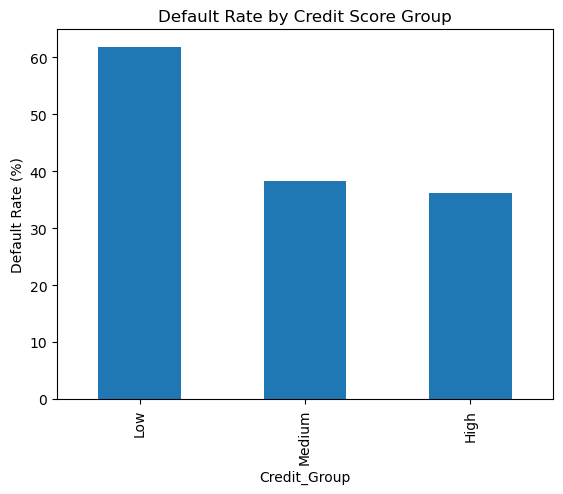

In [12]:
bins = [300, 499, 649, 850]
labels = ['Low', 'Medium', 'High']
pf['Credit_Group'] = pd.cut(pf['Credit_Score'], bins=bins, labels=labels)
pf['Defaulted']=pf['Defaulted'].map({'Yes':1,'No':0})
credit_risk = pf.groupby('Credit_Group')['Defaulted'].mean() * 100
print(credit_risk)
credit_risk.plot(kind='bar')
plt.title('Default Rate by Credit Score Group')
plt.ylabel('Default Rate (%)')
plt.show()

### Q2

In [13]:
correlation = pf[["Income","Defaulted"
]].corr()

print(correlation)

             Income  Defaulted
Income     1.000000  -0.075036
Defaulted -0.075036   1.000000


### Q4

Previous_Default
No     40.322581
Yes    76.923077
Name: Defaulted, dtype: float64


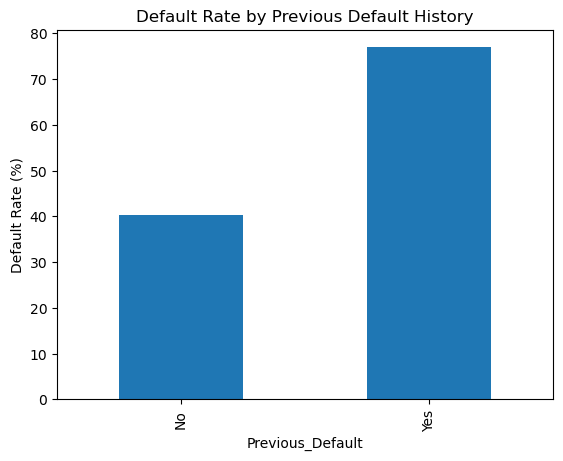

In [14]:
previous_default_risk = pf.groupby('Previous_Default')['Defaulted'].mean() * 100
print(previous_default_risk)
previous_default_risk.plot(kind='bar')
plt.title('Default Rate by Previous Default History')
plt.ylabel('Default Rate (%)')
plt.show()

### Task 4 Question 1

Risk_Level
Medium Risk    60
Low Risk       48
High Risk      42
Name: count, dtype: int64


Text(0, 0.5, 'Customer Count')

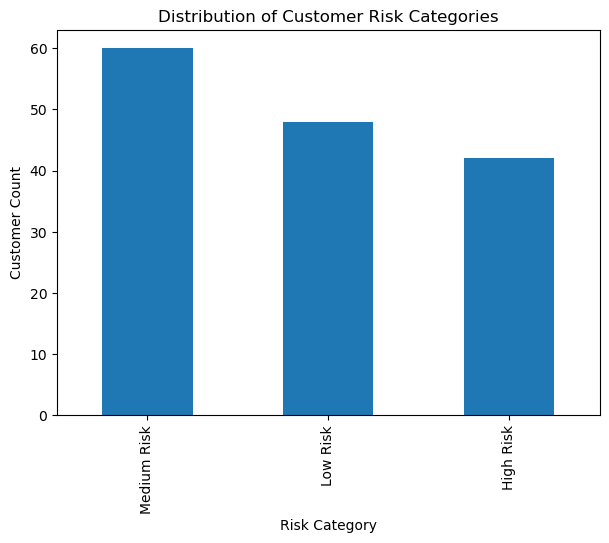

In [15]:
def assign_risk(row):
    score = 0
    if row['Credit_Score'] < 550:
        score += 3
    elif row['Credit_Score'] < 650:
        score += 1
    
    if row['Previous_Default'] == 'Yes':
        score += 2
    
    if row['Employment_Status'] == 'Unemployed':
        score += 1
    
    if row['Loan_Term'] <= 12:
        score += 1
    
    if score >= 4:
        return 'High Risk'
    elif score >= 2:
        return 'Medium Risk'
    else:
        return 'Low Risk'

pf['Risk_Level'] = pf.apply(assign_risk, axis=1)

print(pf['Risk_Level'].value_counts())
risk_counts = pf['Risk_Level'].value_counts()
plt.figure(figsize=(7,5))
risk_counts.plot(kind='bar')
plt.title('Distribution of Customer Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Customer Count')

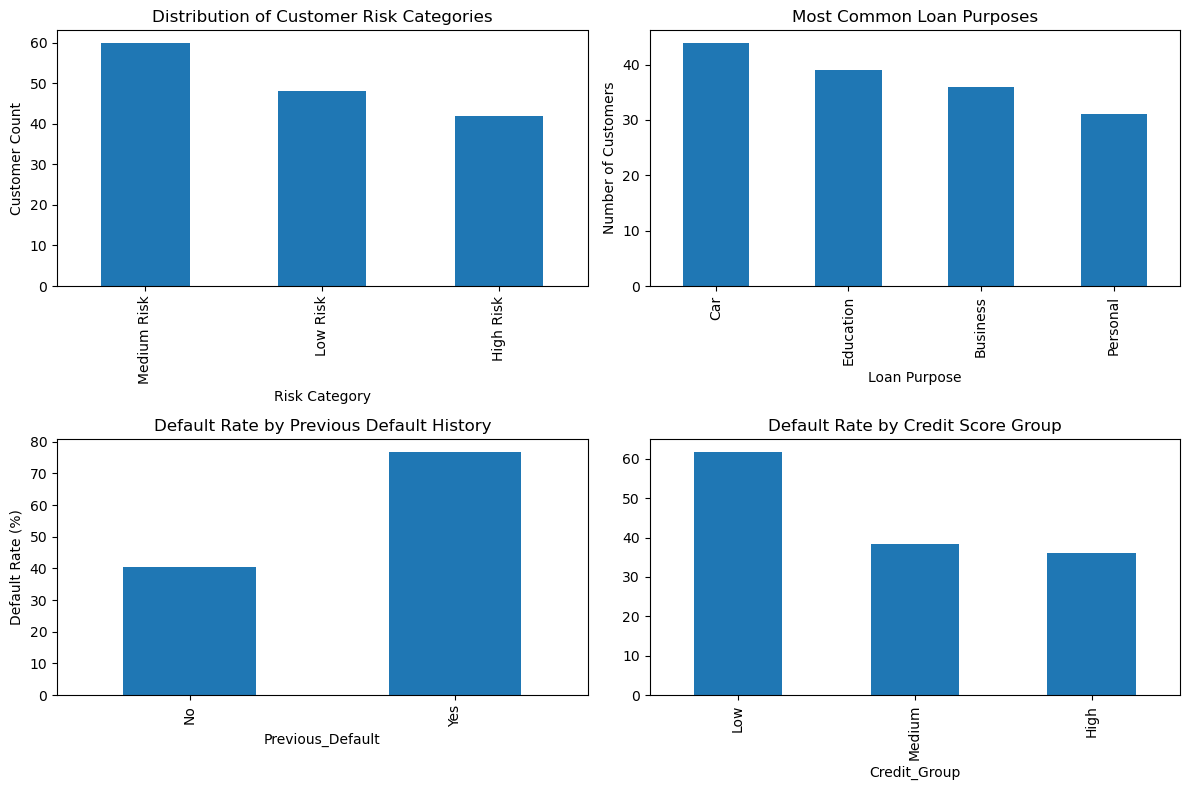

In [20]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
risk_counts.plot(kind='bar')
plt.title('Distribution of Customer Risk Categories')
plt.xlabel('Risk Category')
plt.ylabel('Customer Count')

plt.subplot(2,2,2)


loan_purpose.plot(kind='bar')
plt.xlabel('Loan Purpose')
plt.ylabel('Number of Customers')
plt.title('Most Common Loan Purposes')
plt.subplot(2,2,3)

previous_default_risk.plot(kind='bar')
plt.title('Default Rate by Previous Default History')
plt.ylabel('Default Rate (%)')

plt.subplot(2,2,4)

credit_risk.plot(kind='bar')
plt.title('Default Rate by Credit Score Group')

plt.tight_layout()